In [11]:
# %% CELL 1: Setup and Imports
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from sklearn.model_selection import train_test_split
import time
import os

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# %% CELL 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create output directory
OUTPUT_DIR = '/content/drive/MyDrive/word_problem_results/B3'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Results will be saved to: {OUTPUT_DIR}")

# %% CELL 3: Set Data Directory
DATA_DIR = '/content/B3'

# %% CELL 4: Load Datasets
df_synthetic = pd.read_csv(os.path.join(DATA_DIR, 'b3_synthetic_100k.csv'))
df_augmented = pd.read_csv(os.path.join(DATA_DIR, 'b3_augmented_100k.csv'))
df_hard = pd.read_csv(os.path.join(DATA_DIR, 'b3_hard_100k.csv'))

datasets = {
    'synthetic': df_synthetic,
    'augmented': df_augmented,
    'hard': df_hard
}

for name, df in datasets.items():
    print(f"{name}: {len(df)} rows, {df['label'].sum()} identity, {len(df) - df['label'].sum()} non-identity")

# %% CELL 5: Quick Data Check
print(f"\nSynthetic: {len(df_synthetic)} rows")
print(f"Augmented: {len(df_augmented)} rows")
print(f"Hard: {len(df_hard)} rows")
print(df_synthetic.head())

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results will be saved to: /content/drive/MyDrive/word_problem_results/B3
synthetic: 100000 rows, 50000 identity, 50000 non-identity
augmented: 100000 rows, 50000 identity, 50000 non-identity
hard: 100000 rows, 50000 identity, 50000 non-identity

Synthetic: 100000 rows
Augmented: 100000 rows
Hard: 100000 rows
                                                word  label  length  \
0  S2 S2 S2 s1 s2 S2 S1 s2 s1 s2 S1 s2 s2 s2 S2 S...      0      27   
1  s1 s1 S2 s2 s1 s2 S1 s2 s1 s1 S1 s1 s2 s1 s1 s...      1      42   
2  s1 S2 s1 S1 s2 s2 s1 S1 S2 s1 S2 s1 S2 s2 s1 s...      0      30   
3  s2 S1 s1 s2 S2 S1 s2 S1 s1 s1 s2 S2 S2 s1 S2 s...      0      49   
4  s1 S2 s1 S2 s2 S1 s2 s2 S1 S1 S2 s2 s2 s1 s1 s...      1      38   

              source  
0  b3_synthetic_100k  
1  b3_synthetic_100k  
2  b3_synthetic_100k  
3 

In [13]:
# %% CELL 6: Tokenizer
# B3 alphabet: s1, S1 (inverse), s2, S2 (inverse) - space-separated
sample_word = df_synthetic['word'].iloc[0]
print(f"Sample word: '{sample_word}'")

if ' ' in sample_word:
    # Space-separated tokens (s1 S1 s2 S2)
    VOCAB = {'<PAD>': 0, 's1': 1, 'S1': 2, 's2': 3, 'S2': 4}
    def encode(word):
        return [VOCAB.get(t, 0) for t in word.split()]
else:
    # Character-based fallback
    VOCAB = {'<PAD>': 0}
    all_chars = set()
    for word in df_synthetic['word'].head(1000):
        all_chars.update(word)
    for i, c in enumerate(sorted(all_chars)):
        VOCAB[c] = i + 1
    def encode(word):
        return [VOCAB.get(c, 0) for c in word]

VOCAB_SIZE = len(VOCAB)
print(f"Vocab ({VOCAB_SIZE} tokens): {VOCAB}")
print(f"encode('{sample_word}') = {encode(sample_word)}")

# %% CELL 7: Dataset Class
class WordProblemDataset(Dataset):
    def __init__(self, words, labels):
        self.words = words
        self.labels = labels

    def __len__(self):
        return len(self.words)

    def __getitem__(self, idx):
        encoded = encode(self.words[idx])
        return encoded, self.labels[idx], len(encoded)

def collate_fn(batch):
    words, labels, lengths = zip(*batch)
    max_len = max(lengths)

    padded = []
    for w in words:
        padded.append(w + [0] * (max_len - len(w)))

    sorted_indices = sorted(range(len(lengths)), key=lambda i: lengths[i], reverse=True)

    padded_sorted = [padded[i] for i in sorted_indices]
    labels_sorted = [labels[i] for i in sorted_indices]
    lengths_sorted = [lengths[i] for i in sorted_indices]

    return (
        torch.tensor(padded_sorted),
        torch.tensor(labels_sorted, dtype=torch.float),
        torch.tensor(lengths_sorted)
    )

# %% CELL 8: LSTM Model
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128,
                 num_layers=2, dropout=0.3, bidirectional=True):
        super().__init__()
        self.bidirectional = bidirectional

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim

        self.classifier = nn.Sequential(
            nn.Linear(lstm_output_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, (hidden, _) = self.lstm(packed)

        if self.bidirectional:
            hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            hidden = hidden[-1]

        return self.classifier(hidden).squeeze(-1)

# %% CELL 9: Transformer Model
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, num_heads=4,
                 num_layers=2, dropout=0.3, max_len=200):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_encoding = nn.Embedding(max_len, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 1)
        )

    def forward(self, input_ids, lengths):
        batch_size, seq_len = input_ids.shape

        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, -1)
        embedded = self.embedding(input_ids) + self.pos_encoding(positions)

        mask = (input_ids == 0)

        output = self.transformer(embedded, src_key_padding_mask=mask)

        mask_expanded = (~mask).unsqueeze(-1).float()
        pooled = (output * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)

        return self.classifier(pooled).squeeze(-1)

print("Models defined: LSTMClassifier, TransformerClassifier")

# %% CELL 10: Training Function
def train_model(model, train_loader, val_loader, epochs=30, patience=5, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    best_val_acc = 0
    best_model_state = None
    patience_counter = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for input_ids, labels, lengths in train_loader:
            input_ids, labels, lengths = input_ids.to(device), labels.to(device), lengths.to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, lengths)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_acc = train_correct / train_total

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for input_ids, labels, lengths in val_loader:
                input_ids, labels, lengths = input_ids.to(device), labels.to(device), lengths.to(device)
                outputs = model(input_ids, lengths)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                preds = (torch.sigmoid(outputs) > 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    if best_model_state:
        model.load_state_dict(best_model_state)

    return history, best_val_acc

# %% CELL 11: Evaluation Function
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for input_ids, labels, lengths in test_loader:
            input_ids, labels, lengths = input_ids.to(device), labels.to(device), lengths.to(device)
            outputs = model(input_ids, lengths)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    return accuracy, all_preds, all_labels

# %% CELL 12: Length Generalization Test
def test_length_generalization(model, df, train_max_len=50):
    long_df = df[df['length'] > train_max_len].copy()
    if len(long_df) == 0:
        return None, 0

    dataset = WordProblemDataset(long_df['word'].tolist(), long_df['label'].tolist())
    loader = DataLoader(dataset, batch_size=64, collate_fn=collate_fn)

    acc, _, _ = evaluate_model(model, loader)
    return acc, len(long_df)

# %% CELL 13: Run Single Experiment
def run_experiment(df, model_type, seed, dataset_name):
    print(f"\n{'='*60}")
    print(f"Model: {model_type} | Dataset: {dataset_name} | Seed: {seed}")
    print(f"{'='*60}")

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    train_df, temp_df = train_test_split(df, test_size=0.3, random_state=seed)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=seed)

    train_dataset = WordProblemDataset(train_df['word'].tolist(), train_df['label'].tolist())
    val_dataset = WordProblemDataset(val_df['word'].tolist(), val_df['label'].tolist())
    test_dataset = WordProblemDataset(test_df['word'].tolist(), test_df['label'].tolist())

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=64, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=64, collate_fn=collate_fn)

    print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

    if model_type == 'LSTM':
        model = LSTMClassifier(VOCAB_SIZE).to(device)
    else:
        model = TransformerClassifier(VOCAB_SIZE).to(device)

    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parameters: {params:,}")

    start_time = time.time()
    history, best_val_acc = train_model(model, train_loader, val_loader)
    train_time = time.time() - start_time

    test_acc, _, _ = evaluate_model(model, test_loader)

    len_gen_acc, len_gen_count = test_length_generalization(model, df)

    print(f"\nResults:")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Training Time: {train_time:.1f}s")
    if len_gen_acc:
        print(f"  Length Gen Accuracy: {len_gen_acc:.4f} (n={len_gen_count})")

    return {
        'model': model_type,
        'dataset': dataset_name,
        'seed': seed,
        'test_acc': test_acc,
        'val_acc': best_val_acc,
        'train_time': train_time,
        'len_gen_acc': len_gen_acc,
        'len_gen_count': len_gen_count,
        'epochs': len(history['train_acc'])
    }

Sample word: 'S2 S2 S2 s1 s2 S2 S1 s2 s1 s2 S1 s2 s2 s2 S2 S1 s2 S2 S1 s1 s2 S2 s1 S1 S2 s2 s2'
Vocab (5 tokens): {'<PAD>': 0, 's1': 1, 'S1': 2, 's2': 3, 'S2': 4}
encode('S2 S2 S2 s1 s2 S2 S1 s2 s1 s2 S1 s2 s2 s2 S2 S1 s2 S2 S1 s1 s2 S2 s1 S1 S2 s2 s2') = [4, 4, 4, 1, 3, 4, 2, 3, 1, 3, 2, 3, 3, 3, 4, 2, 3, 4, 2, 1, 3, 4, 1, 2, 4, 3, 3]
Models defined: LSTMClassifier, TransformerClassifier


In [14]:
# %% CELL 14: Run All Experiments
SEEDS = [42, 123, 456]
MODEL_TYPES = ['LSTM', 'Transformer']
DATASET_NAMES = ['synthetic', 'augmented', 'hard']

all_results = []

for dataset_name in DATASET_NAMES:
    df = datasets[dataset_name]
    for model_type in MODEL_TYPES:
        for seed in SEEDS:
            result = run_experiment(df, model_type, seed, dataset_name)
            all_results.append(result)

            results_df = pd.DataFrame(all_results)
            results_df.to_csv(f'{OUTPUT_DIR}/b3_results_partial.csv', index=False)

print("\n" + "="*60)
print("ALL EXPERIMENTS COMPLETE")
print("="*60)



Model: LSTM | Dataset: synthetic | Seed: 42
Train: 70000 | Val: 15000 | Test: 15000
Parameters: 627,265
Epoch 1/30 | Train Acc: 0.9366 | Val Acc: 0.9831
Epoch 2/30 | Train Acc: 0.9833 | Val Acc: 0.9890
Epoch 3/30 | Train Acc: 0.9889 | Val Acc: 0.9914
Epoch 4/30 | Train Acc: 0.9933 | Val Acc: 0.9954
Epoch 5/30 | Train Acc: 0.9958 | Val Acc: 0.9958
Epoch 6/30 | Train Acc: 0.9966 | Val Acc: 0.9975
Epoch 7/30 | Train Acc: 0.9976 | Val Acc: 0.9963
Epoch 8/30 | Train Acc: 0.9983 | Val Acc: 0.9970
Epoch 9/30 | Train Acc: 0.9984 | Val Acc: 0.9974
Epoch 10/30 | Train Acc: 0.9987 | Val Acc: 0.9984
Epoch 11/30 | Train Acc: 0.9990 | Val Acc: 0.9980
Epoch 12/30 | Train Acc: 0.9988 | Val Acc: 0.9983
Epoch 13/30 | Train Acc: 0.9989 | Val Acc: 0.9983
Epoch 14/30 | Train Acc: 0.9994 | Val Acc: 0.9981
Epoch 15/30 | Train Acc: 0.9993 | Val Acc: 0.9984
Early stopping at epoch 15

Results:
  Test Accuracy: 0.9989
  Training Time: 271.7s

Model: LSTM | Dataset: synthetic | Seed: 123
Train: 70000 | Val: 150

Results saved to /content/drive/MyDrive/word_problem_results/B3/b3_results.csv

SUMMARY TABLE
      model   dataset  seed  test_acc  val_acc  train_time  len_gen_acc  len_gen_count  epochs
       LSTM synthetic    42  0.998867 0.998400  271.727291          NaN              0      15
       LSTM synthetic   123  0.998733 0.999200  289.873324          NaN              0      16
       LSTM synthetic   456  0.998667 0.998733  216.581429          NaN              0      12
Transformer synthetic    42  0.986467 0.992733  137.407464          NaN              0      13
Transformer synthetic   123  0.990467 0.991467   84.633538          NaN              0       8
Transformer synthetic   456  0.991000 0.991333  168.682841          NaN              0      16
       LSTM augmented    42  0.998800 0.999067  375.076211          NaN              0      21
       LSTM augmented   123  0.999067 0.998600  365.509300          NaN              0      20
       LSTM augmented   456  0.998867 0.999467  410

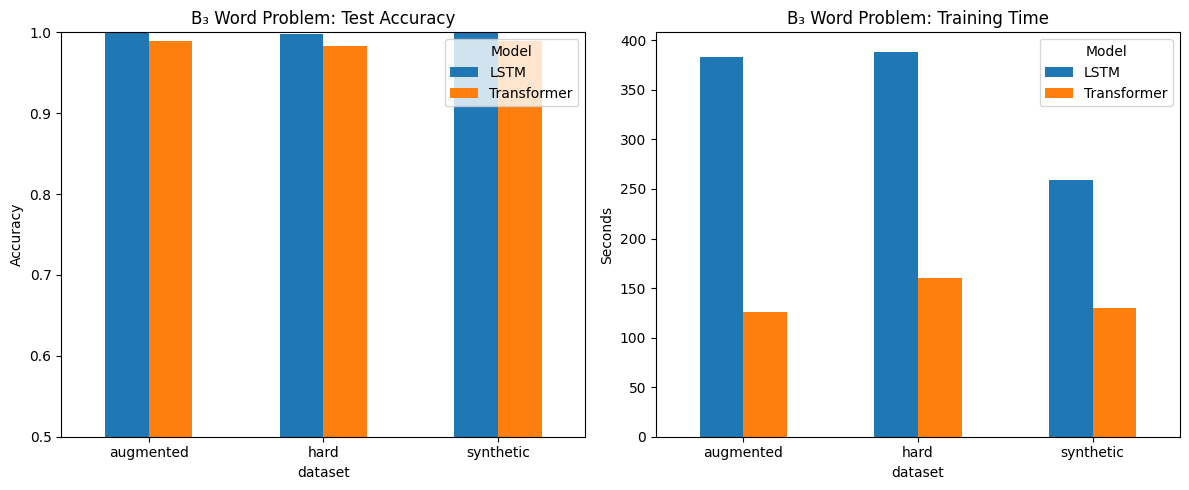


Visualization saved to /content/drive/MyDrive/word_problem_results/B3/b3_results.png


In [15]:
# %% CELL 15: Save Final Results
results_df = pd.DataFrame(all_results)
results_df.to_csv(f'{OUTPUT_DIR}/b3_results.csv', index=False)
print(f"Results saved to {OUTPUT_DIR}/b3_results.csv")

print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(results_df.to_string(index=False))

# %% CELL 16: Summary Statistics
summary = results_df.groupby(['model', 'dataset']).agg({
    'test_acc': ['mean', 'std'],
    'train_time': 'mean'
}).round(4)

print("\n" + "="*60)
print("AGGREGATED RESULTS (mean ± std)")
print("="*60)
print(summary)

summary.to_csv(f'{OUTPUT_DIR}/b3_summary.csv')

# %% CELL 17: Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pivot = results_df.pivot_table(values='test_acc', index='dataset', columns='model', aggfunc='mean')
pivot.plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('B₃ Word Problem: Test Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(title='Model')

pivot_time = results_df.pivot_table(values='train_time', index='dataset', columns='model', aggfunc='mean')
pivot_time.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('B₃ Word Problem: Training Time')
axes[1].set_ylabel('Seconds')
axes[1].legend(title='Model')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/b3_results.png', dpi=150)
plt.show()

print(f"\nVisualization saved to {OUTPUT_DIR}/b3_results.png")